# Loyalty Programme

Imagine a café or a shop that offers its customers a loyalty program: they can save bonus points from each purchase — say, $\alpha=0.1$ ($10\%$) of the check amount. These bonuses can later be used to cover up to $\beta = 0.5$ ($50\%$) of a future purchase. If the current bonus balance is smaller than 50% of the check, all available bonuses are spent.

Each time, the customer must choose between saving or spending — the two options are **mutually exclusive**. How should one decide which action to take?

## Optimising Expenses for the Year

Let's begin from a following model. We assume we know the values $n=100$ receipts (representing approximately 100 visits per year), i.e. a vector $$\mathbf{p} = (p_1, p_2, \dots, p_n),$$ where $p_k \in [200, 3500]$ (in roubles).

Our goal is to **maximize the total discount** for this sequence of purchases.

Each time we choose to **save** bonuses, the bonus balance increases by $\alpha p_k$. Each time we choose to **spend**, bonuses are deducted from the account (if it is not empty), and the corresponding receipt is reduced by $\beta p_k$.

The decision sequence is represented by $$\mathbf{x} = (x_1, x_2, \dots, x_n), \quad x_k \in \{0, 1\} = \mathbb{B},$$ where $x_k = 0$ corresponds to saving, $x_k = 1$ corresponds to spending.

For simplicity, we round down in calculations: $$a_k = \lfloor \alpha p_k \rfloor, \quad s_k = \lfloor \beta p_k \rfloor.$$

We also introduce an initial (welcome) bonus balance $B_0 \in \mathbb{Z}_{\geqslant 0}$. In all simulations, we assume $B_0 = 0$ – life is tough.

The balance at step $k$ of the algorithm is given recursively by $$B_k = B_{k-1} + a_k (1-x_k) - t_k x_k,$$ where $$t_k = \min{(B_{k-1}, s_k)}$$ since bonuses cannot be spent from an empty account.

The optimisation problem is formulated as follows: $$ \begin{cases} f_{\mathbf{p}} (\mathbf{x}) = \sum_{k=1}^n (p_k - t_k x_k) \longrightarrow \min \\ \forall  k \in \overline{1, n} \quad B_k \geqslant 0 \end{cases} $$ or, equivalently, $$ \begin{cases} f_{\mathbf{p}} (\mathbf{x}) = \sum_{k=1}^n t_k x_k \longrightarrow \max \\ \forall  k \in \overline{1, n} \quad B_k \geqslant 0 \end{cases} $$

To optimise the objective we use the **dynamic programming (DP)** method.

We define the function $$\text{DP}[k][b] = \text{min sum spend on step } k \text{ having balance } b,$$ where $k \in \overline{1, n}$ and $b \in \overline{0, B_{\text{max}}}, \,\, B_{\text{max}}=\sum_{k=1}^n a_k$ is the maximum possible balance, achieved if the customer always chooses to save.

**Initialisation:** $$\text{DP}[0][B_0] = 0, \quad \text{DP}[0][b] = +\infty \,\, \mathrm{for} \,\, b \neq B_0.$$
**Recurrence relation (step $k$):**
1. **Save** ($x_k = 0$): $$b' = b + a_k, \quad \text{DP}[k][b'] \leftarrow \min{\big( \text{DP}[k][b'], \, \text{DP}[k-1][b] + p_k \big)}.$$
2. **Spend** ($x_k = 1$): $$b' = b - t_k, \quad \text{DP}[k][b'] \leftarrow \min{\big( \text{DP}[k][b'], \, \text{DP}[k-1][b] + p_k - t_k \big)},$$ where $t_k = \min{(B_{k-1}, s_k)}$.

**Result:**

The answer to the problem is obtained as $$ \min_{b \geqslant 0}{\text{DP}[n][b]} $$ that is, the minimal total spend among all valid non-negative balances at the final step.

This DP table $\text{DP}[k][b]$ also allows us to **restore** the optimal decision sequence $\mathbf{x} = (x_1, x_2, \dots, x_n)$ by backtracking. Additionally, we can compute the **total amount saved** through bonuses during the optimisation process.

In [1]:
def solve_sequential_dp(p, alpha=0.1, beta=0.5, B0=0):
    n = len(p)
    # rounding
    a = [int(alpha * pk) for pk in p]
    s = [int(beta  * pk) for pk in p]

    B_max = B0 + sum(a)
    # cur: dictionary balance -> cost
    cur = {B0: 0}
    # parent[k] stores for every step k (1..n) map balance->(prev_balance, choice)
    parent = [dict() for _ in range(n+1)]

    for k in range(1, n+1):
        pk = p[k-1]
        ak = a[k-1]
        sk = s[k-1]
        nxt = dict()
        for balance, cost in cur.items():
            # save
            b0 = balance + ak
            if b0 <= B_max:
                newcost = cost + pk
                if b0 not in nxt or newcost < nxt[b0]:
                    nxt[b0] = newcost
                    parent[k][b0] = (balance, 0)
            # spend, if can afford
            if balance > 0:
                tk = min(balance, sk)
                b1 = balance - tk
                newcost = cost + (pk - tk)
                if b1 not in nxt or newcost < nxt[b1]:
                    nxt[b1] = newcost
                    parent[k][b1] = (balance, 1)
        cur = nxt
        if not cur:
            # no feasible states
            break

    # final choice of best balance
    if not cur:
        return None  # no feasible strategy
    final_balance, min_cost = min(cur.items(), key=lambda kv: kv[1])

    # retrival of x
    x = [0]*n
    b = final_balance
    for k in range(n, 0, -1):
        prev_balance, choice = parent[k][b]
        x[k-1] = choice
        b = prev_balance

    return {
        'x': x,
        'min_cost': min_cost,
        'final_balance': final_balance,
    }

To verify that the dynamic programming algorithm works correctly, we can run a small experiment on a randomly generated sequence of check values.

Let $$n=100, \quad p_k \in [200, 3500],$$ and set the model parameters $$\alpha=0.1, \quad \beta=0.5, \quad B_0 = 0.$$

In [2]:
import random

random.seed(42)

p_min, p_max = 200, 3500

p = [random.randint(p_min, p_max) for _ in range(100)]

result = solve_sequential_dp(p, alpha=0.1, beta=0.5, B0=0)
result_summary = {
    "min_cost": result["min_cost"],
    "final_balance": result["final_balance"],
    "num_spend": sum(result["x"]),
    "num_save": len(result["x"]) - sum(result["x"]),
    "total_sum": sum(p),
    "total_economy": sum(p) - result["min_cost"],
}
print(result_summary)

{'min_cost': 162817, 'final_balance': 0, 'num_spend': 29, 'num_save': 71, 'total_sum': 177593, 'total_economy': 14776}


It is interesting to visualise the dynamics of the process, i.e. the **trajectory of the bonus balance** over time. This plot shows how the accumulated bonuses evolve depending on the sequence of “save” and “spend” decisions. The resulting trajectory provides an intuitive way to understand how the strategy manages the available balance throughout the year.

In [3]:
def compute_balance_trajectory(p, x, alpha=0.1, beta=0.5, B0=0):
    """Compute cumulative balance evolution for given decisions."""
    a = [int(alpha * pk) for pk in p]
    s = [int(beta * pk) for pk in p]
    balances = [B0]
    b = B0
    for k in range(len(p)):
        if x[k] == 0:  # save
            b += a[k]
        else:           # spend
            b -= s[k]
        balances.append(b)
    return balances

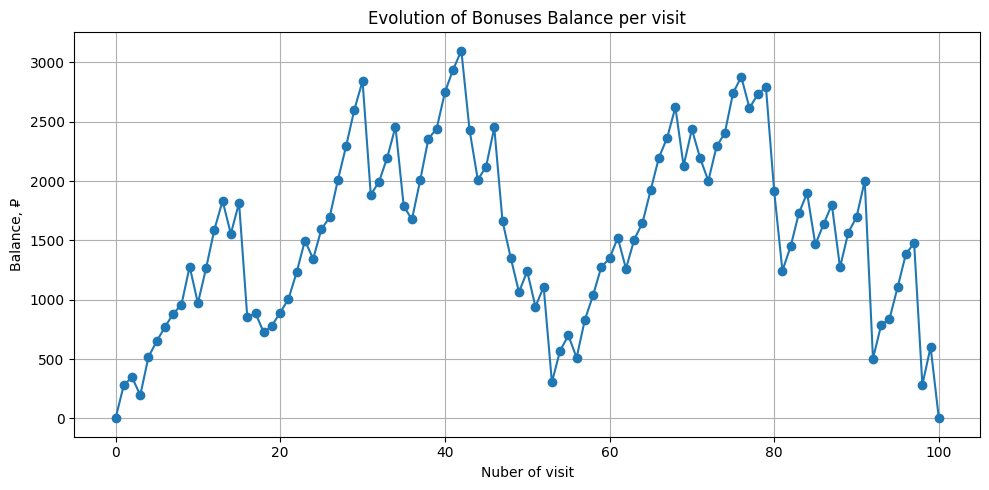

In [4]:
import matplotlib.pyplot as plt

balances = compute_balance_trajectory(p, result["x"], alpha=0.1, beta=0.5, B0=0)

plt.figure(figsize=(10, 5))
plt.plot(range(len(balances)), balances, marker='o', linewidth=1.5)
plt.title("Evolution of Bonuses Balance per visit")
plt.xlabel("Nuber of visit")
plt.ylabel("Balance, ₽")
plt.grid(True)
plt.tight_layout()
plt.show()

Now let's look at some statistics. We will run $m=100$ trials, each with $n$ drawn randomly from the range $[80, 120]$. Then we will plot three graphs to analyse the results.

The first graph divides all prices into bins of width $100$ (i.e. $[200, 299], \,\, [300, 399]$ and so on) and shows the **fraction of “spend” decisions** within each bin. The second graph presents the **distribution of prices** across these bins for reference. Finally, the third graph illustrates the **frequency distribution of all balance values** observed across the $m=100$ simulated trajectories.

In [5]:
# Parameters
m = 100        # number of trials
alpha = 0.1
beta = 0.5
random.seed(42)

# Initialize lists for storing results
bin_edges = list(range(p_min, p_max + 1, 100))
bin_labels = [f"[{edge},{edge+99}]" for edge in bin_edges[:-1]] + [f"[{bin_edges[-1]}]"]

bin_counts = [0]*len(bin_labels)
bin_spend_counts = [0]*len(bin_labels)
all_balances = []  # store all intermediate balances
total_checks = 0

# Loop for trials
for trial in range(m):
    n = random.randint(80, 120)  # number of visits per trial
    p = [random.randint(p_min, p_max) for _ in range(n)]
    result = solve_sequential_dp(p, alpha=alpha, beta=beta, B0=0)
    if result is None:
        continue
    x = result["x"]
    total_checks += n

    # Update bin counts and spend counts for histograms
    for pk, xi in zip(p, x):
        idx = len(bin_labels)-1 if pk == p_max else (pk - p_min)//100
        bin_counts[idx] += 1
        if xi == 1:
            bin_spend_counts[idx] += 1

    # Reconstruct balance trajectory and save to all_balances
    B = [0]
    for pk, xk in zip(p, result["x"]):
        if xk == 0:  # save
            B.append(B[-1] + int(alpha * pk))
        else:        # spend (may be partial)
            spend_amount = min(int(beta * pk), B[-1])
            B.append(B[-1] - spend_amount)
    all_balances.extend(B)

# --- Compute fractions (share of spending) ---
fractions = [(bin_spend_counts[i] / bin_counts[i]) if bin_counts[i] > 0 else 0.0
             for i in range(len(bin_labels))]

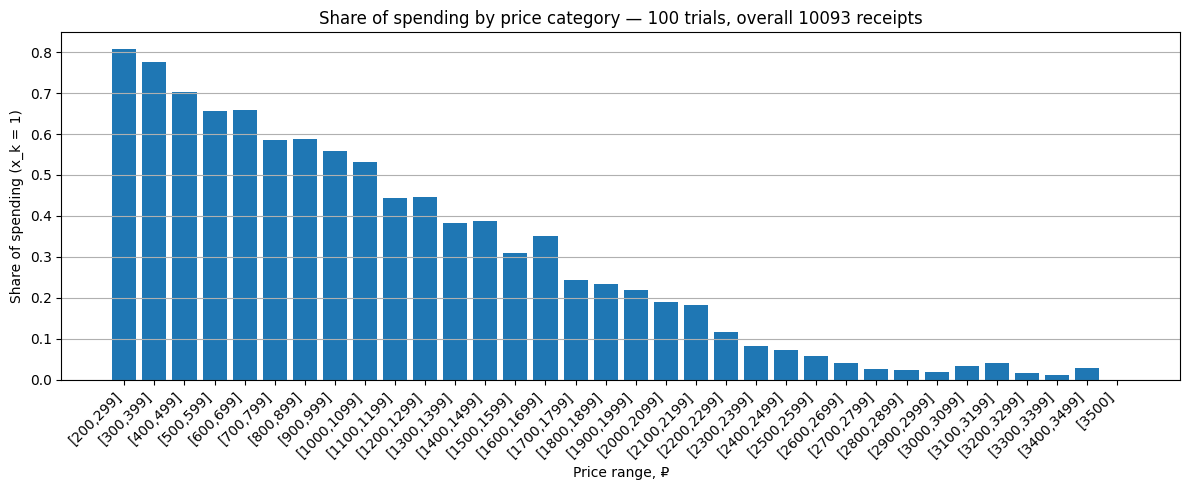

In [6]:
# 1. Share of spending by price category
plt.figure(figsize=(12,5))
x_pos = range(len(bin_labels))
plt.bar(x_pos, fractions)
plt.xticks(x_pos, bin_labels, rotation=45, ha='right')
plt.xlabel("Price range, ₽")
plt.ylabel("Share of spending (x_k = 1)")
plt.title(f"Share of spending by price category — {m} trials, overall {total_checks} receipts")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Here we can see that it’s usually better to save bonuses from expensive receipts that generate more rewards, and spend them on cheaper ones.

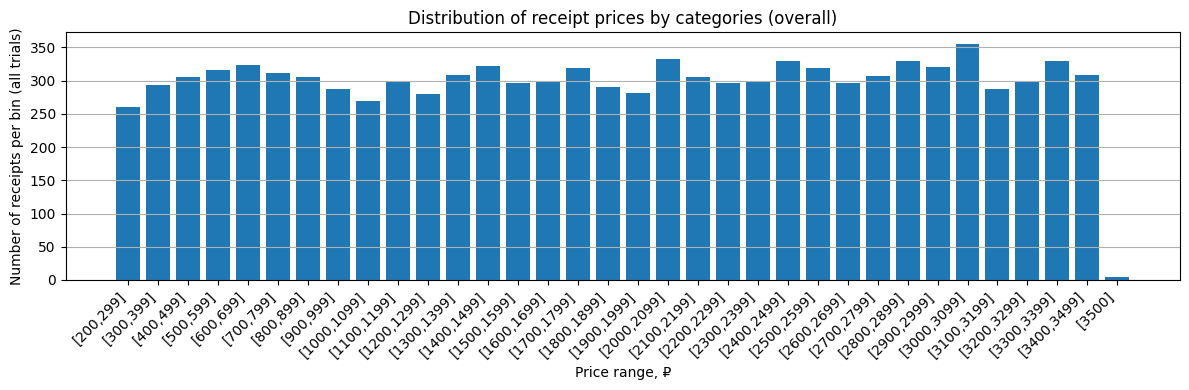

In [7]:
# 2. Number of receipts per bin (all trials)
plt.figure(figsize=(12,4))
plt.bar(x_pos, bin_counts)
plt.xticks(x_pos, bin_labels, rotation=45, ha='right')
plt.xlabel("Price range, ₽")
plt.ylabel("Number of receipts per bin (all trials)")
plt.title("Distribution of receipt prices by categories (overall)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

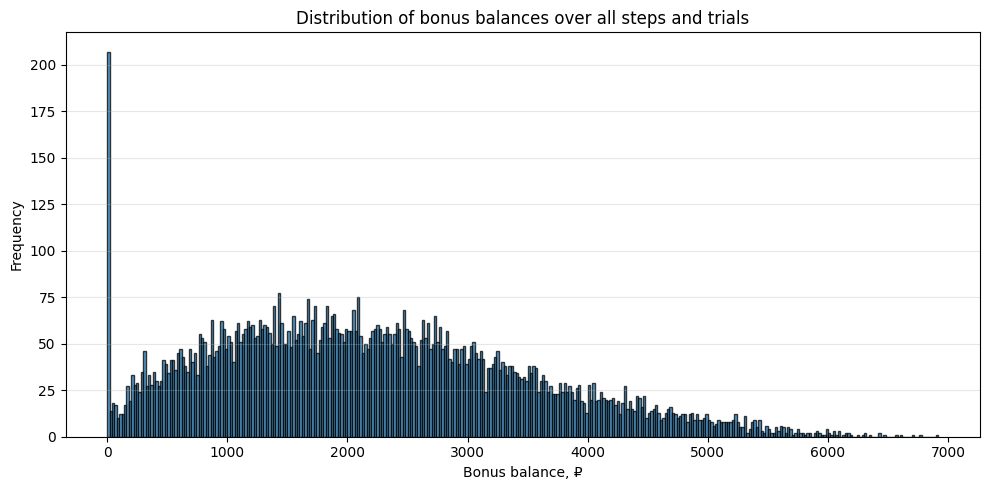

In [8]:
# 3. Distribution of all balances (from all steps and trials)
plt.figure(figsize=(10,5))
plt.hist(all_balances, bins=range(0, max(all_balances)+20, 20), edgecolor='black', alpha=0.75)
plt.xlabel("Bonus balance, ₽")
plt.ylabel("Frequency")
plt.title("Distribution of bonus balances over all steps and trials")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Studying $\alpha$ and $\beta$ parameters

Another question arises out of curiosity: how do the *cashback rate* $\alpha$ and the *discount rate* $\beta$ affect the benefit that customers obtain from the loyalty program?

Some aspects are intuitive — the larger $\alpha$, the more bonuses a customer accumulates, which directly increases profit. However, the influence of $\beta$ is less obvious and therefore more interesting to examine.

To explore this, we will plot a surface showing the share of total money that was discounted.

In [9]:
import numpy as np

random.seed(42)
m = 10
p_min, p_max = 200, 3000
n = 100

alpha_values = [0.01, 0.02, 0.03] + list(np.arange(0.05, 0.51, 0.05))
beta_values = np.arange(0.1, 1.01, 0.1)
surface = np.zeros((len(alpha_values), len(beta_values)))

# --- Simulation ---
for i, alpha in enumerate(alpha_values):
    for j, beta in enumerate(beta_values):
        savings_ratios = []
        for _ in range(m):
            p = [random.randint(p_min, p_max) for _ in range(n)]
            total = sum(p)
            result_cost = solve_sequential_dp(p, alpha=alpha, beta=beta, B0=0)['min_cost']
            if result_cost is not None:
                savings_ratios.append((total - result_cost) / total)
        surface[i, j] = np.mean(savings_ratios) if savings_ratios else np.nan
        # print(f"alpha={alpha:.2f}, beta={beta:.2f}, mean_saving={surface[i,j]:.4f}")

# --- Find extremes ---
max_idx = np.unravel_index(np.nanargmax(surface), surface.shape)
min_idx = np.unravel_index(np.nanargmin(surface), surface.shape)
alpha_max, beta_max = alpha_values[max_idx[0]], beta_values[max_idx[1]]
alpha_min, beta_min = alpha_values[min_idx[0]], beta_values[min_idx[1]]
max_val, min_val = surface[max_idx], surface[min_idx]

As seen from the surface, while a larger $\beta$ increases customer profit, the sensitivity of the outcome to $\beta$ is significantly lower than to $\alpha$.

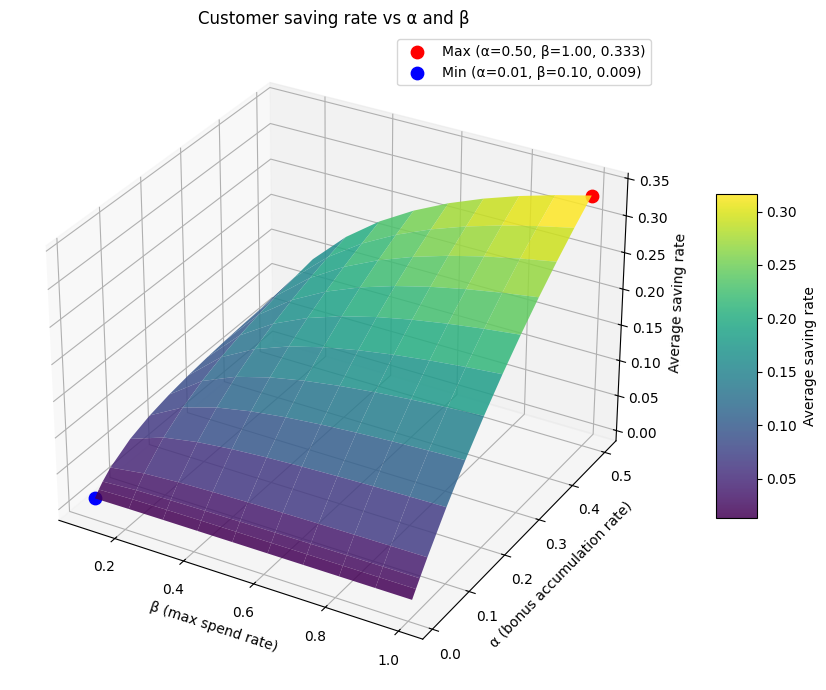

In [10]:
# --- 3D Surface plot ---
A, B = np.meshgrid(beta_values, alpha_values)

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A, B, surface, cmap='viridis', edgecolor='none', alpha=0.85)

# Mark max and min points
ax.scatter(beta_max, alpha_max, max_val, color='red', s=80, label=f"Max (α={alpha_max:.2f}, β={beta_max:.2f}, {max_val:.3f})")
ax.scatter(beta_min, alpha_min, min_val, color='blue', s=80, label=f"Min (α={alpha_min:.2f}, β={beta_min:.2f}, {min_val:.3f})")

ax.set_xlabel("β (max spend rate)")
ax.set_ylabel("α (bonus accumulation rate)")
ax.set_zlabel("Average saving rate")
ax.set_title("Customer saving rate vs α and β")
ax.legend()
fig.colorbar(surf, shrink=0.5, aspect=8, label="Average saving rate")
plt.tight_layout()
plt.show()

A look at the section where $\alpha$ is fixed and $\beta$ varies.

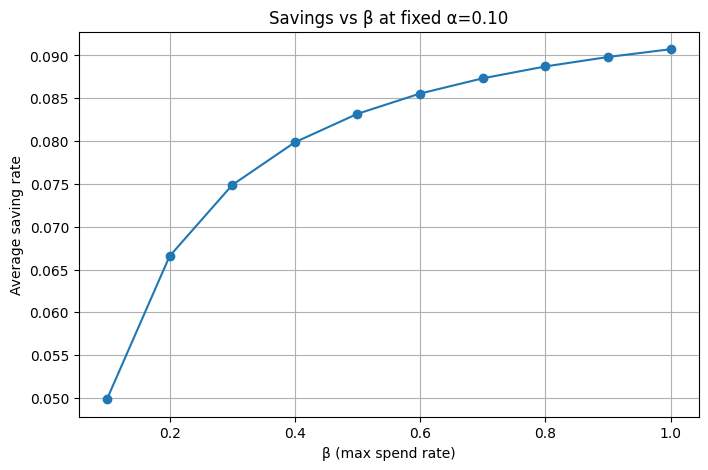

In [11]:
fixed_alpha_idx = 4
fixed_alpha = alpha_values[fixed_alpha_idx]
plt.figure(figsize=(8,5))
plt.plot(beta_values, surface[fixed_alpha_idx, :], marker='o')
plt.xlabel("β (max spend rate)")
plt.ylabel("Average saving rate")
plt.title(f"Savings vs β at fixed α={fixed_alpha:.2f}")
plt.grid(True)
plt.show()

Here $\beta$ is fixed, instead.

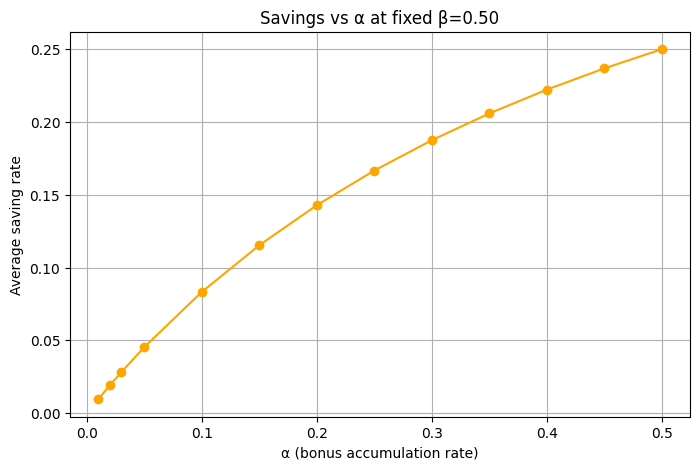

In [12]:
fixed_beta_idx = 4
fixed_beta = beta_values[fixed_beta_idx]
plt.figure(figsize=(8,5))
plt.plot(alpha_values, surface[:, fixed_beta_idx], marker='o', color='orange')
plt.xlabel("α (bonus accumulation rate)")
plt.ylabel("Average saving rate")
plt.title(f"Savings vs α at fixed β={fixed_beta:.2f}")
plt.grid(True)
plt.show()

## Logistic Regression Classification

Finally, we can use our optimiser to generate a sufficiently large dataset of prices, balances, and decisions. We can then train a Logistic Regression model to predict the optimal decision based on the check value and the current balance.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [14]:
# Generate dataset
m = 1000  # number of trials
alpha = 0.1
beta = 0.5
random.seed(42)

# Lists for collecting features and labels
X = []  # features: balance and price
y = []  # labels: 0 or 1 (0 = save, 1 = spend)

# Generate the data for m trials
for trial in range(m):
    n = random.randint(80, 120)
    p = [random.randint(p_min, p_max) for _ in range(n)]
    result = solve_sequential_dp(p, alpha=alpha, beta=beta, B0=0)
    if result is None:
        continue

    # Reconstruct the balance trajectory and collect the features
    B = [0]
    for pk, xk in zip(p, result["x"]):
        balance_before = B[-1]
        X.append([balance_before, pk])  # feature: [balance_before, price]
        y.append(xk)  # label: 0 or 1 (save or spend)

        if xk == 0:  # save
            B.append(balance_before + int(alpha * pk))
        else:        # spend (may be partial)
            spend_amount = min(int(beta * pk), balance_before)
            B.append(balance_before - spend_amount)

# Convert X and y to numpy arrays
X = np.array(X)
y = np.array(y)

In [15]:
# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
# Train a logistic regression classifier
clf = LogisticRegression()
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
# Predict and evaluate the model
y_pred = clf.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86     21294
           1       0.66      0.58      0.61      8630

    accuracy                           0.79     29924
   macro avg       0.75      0.73      0.74     29924
weighted avg       0.78      0.79      0.79     29924



The model performs well on the *save* option but shows moderate performance on the *spend* option. This can be explained by the class imbalance.

In [18]:
print(clf.intercept_[0], clf.coef_[0])

1.2058948990703064 [ 0.00033297 -0.00202603]


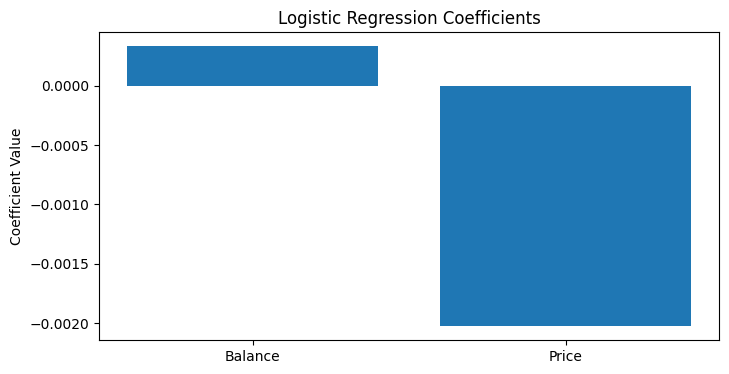

In [19]:
# Plot the coefficients for interpretability
plt.figure(figsize=(8, 4))
plt.bar(['Balance', 'Price'], clf.coef_[0])
plt.ylabel('Coefficient Value')
plt.title('Logistic Regression Coefficients')
plt.show()